<a href="https://colab.research.google.com/github/aligreo/TriEncoder-Unet-Project/blob/main/unet_reem_abdallah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!uv pip install SimpleITK monai

Using Python 3.12.13 environment at: /usr
Resolved 31 packages in 297ms
Prepared 2 packages in 927ms
Installed 2 packages in 47ms
 + monai==1.5.2
 + simpleitk==2.5.4


In [ ]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Suppress specific deprecation and future warnings from libraries
warnings.filterwarnings(
    "ignore",
    message=".*cuda.cudart module is deprecated.*",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message=".*non-tuple sequence for multidimensional indexing.*",
    category=UserWarning,
)

In [ ]:
# from pydrive2.auth import GoogleAuth
# from pydrive2.drive import GoogleDrive
# from google.colab import auth
# from oauth2client.client import GoogleCredentials

In [ ]:
# auth.authenticate_user()
# gauth = GoogleAuth()
# gauth.credentials = GoogleCredentials.get_application_default()
# drive = GoogleDrive(gauth)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load MsLesseg dataset **`kaggle`**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("hongnguyntriu/mslessegdataset")

100%|██████████| 1.43G/1.43G [00:16<00:00, 93.0MB/s]

Extracting files...


## Load msseg dataset

In [ ]:
import os
import glob
import zipfile
import random
from pathlib import Path


# Combined MSSEG + MSLesSeg loader for 3 modalities:
# channel 0 = FLAIR, channel 1 = T1, channel 2 = T2

SEED = 42
random.seed(SEED)

# drive path to load the mmseg dataset
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_EXTRACT_DIR = "/content/MSSEG-Training"


MSLESSEG_ROOT = path if "path" in globals() else "/content/mslessegdataset"


def unzip_if_needed(zip_path, extract_dir):
    """Extract a zip once and return the extracted directory."""
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

In [ ]:
def first_match(files, include_terms, exclude_terms=()):
    """Pick the first file containing all include_terms and none of exclude_terms."""
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

In [ ]:
def find_case_files(case_dir):
    """Find FLAIR, T1, T2, and lesion mask inside one subject/case folder."""
    nii_files = glob.glob(os.path.join(case_dir, "**", "*.nii*"), recursive=True)
    if not nii_files:
        return None

    flair = first_match(nii_files, ["FLAIR"])
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"])
    t1 = first_match(nii_files, ["T1"], exclude_terms=["GADO", "GD", "GAD", "CE", "CONTRAST"])

    # Common label names across MSSEG/MSLesSeg variants.
    label = (
        first_match(nii_files, ["CONSENSUS"])
        or first_match(nii_files, ["LESION"])
        or first_match(nii_files, ["MASK"])
        or first_match(nii_files, ["SEG"])
        or first_match(nii_files, ["GT"])
    )

    # Avoid accidentally selecting an image as a label if names are ambiguous.
    image_set = {p for p in [flair, t1, t2] if p}
    if label in image_set:
        label = None

    if flair and t1 and t2 and label:
        return {"flair": flair, "t1": t1, "t2": t2, "label": label}
    return None

In [ ]:
def collect_dataset(root_dir, source_name):
    """Recursively collect valid cases with all 3 modalities and a label."""
    root_dir = str(root_dir)
    if not os.path.exists(root_dir):
        print(f"WARNING: {source_name} root not found: {root_dir}")
        return []

    all_dirs = [root_dir] + [p for p, _, _ in os.walk(root_dir)]
    cases = []
    seen = set()
    for d in all_dirs:
        item = find_case_files(d)
        if item is None:
            continue
        key = tuple(item[k] for k in ["flair", "t1", "t2", "label"])
        if key in seen:
            continue
        seen.add(key)
        item["source"] = source_name
        item["case_id"] = f"{source_name}_{len(cases):03d}"
        cases.append(item)
    return cases

In [ ]:
msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_files = collect_dataset(msseg_root, "MSSEG")
mslesseg_files = collect_dataset(MSLESSEG_ROOT, "MSLesSeg")

# combine the two datasets
data_dicts = msseg_files + mslesseg_files
random.shuffle(data_dicts)

print(f"MSSEG cases with FLAIR/T1/T2/label: {len(msseg_files)}")
print(f"MSLesSeg cases with FLAIR/T1/T2/label: {len(mslesseg_files)}")
print(f"Total combined cases: {len(data_dicts)}")

MSSEG cases with FLAIR/T1/T2/label: 15
MSLesSeg cases with FLAIR/T1/T2/label: 115
Total combined cases: 130


### Combined-training strategy
This notebook trains one 3-channel model using the fixed channel order `FLAIR, T1, T2`. It only includes cases where all three modalities and a lesion label are found. The train/validation split is stratified by dataset source, and validation prints Dice separately for MSSEG and MSLesSeg so domain performance is visible.


### Preprocessing and Augmentation Pipeline

To train a robust model for Multi-Sequence MS Lesion segmentation, we use a multi-stage pipeline via MONAI:

1.  **Data Loading & Normalization**:
    *   **3-Channel Input**: We combine FLAIR, T1, and T2 into a single multi-channel tensor. The order is fixed as `[FLAIR, T1, T2]` to ensure the model learns consistent features from each modality.
    *   **Binarization**: Labels are converted to binary (0 for background, 1 for lesion) to ensure consistency across datasets.
    *   **Orientation (RAS)**: All volumes are re-oriented to a standard Right-Anterior-Superior coordinate system.
    *   **Resampling (1mm isotropic)**: We standardize the voxel size to $1.0 \times 1.0 \times 1.0$ mm to ensure the model sees consistent physical scales.
    *   **Z-Score Normalization**: Intensities are normalized per channel to have zero mean and unit variance (based on non-zero voxels).

2.  **Training Augmentations**:
    *   **RandCropByPosNegLabeld**: We use a balanced cropping strategy to ensure the model sees lesion areas in 75% of the training patches (pos/neg ratio 3:1).
    *   **Spatial Augmentation**: Random flips (3 axes) and 90-degree rotations to help the model become invariant to orientation.
    *   **Intensity Augmentation**: Random Gaussian noise, intensity scaling/shifting, and Bias Field distortions are added to simulate scanner variability and artifacts common in MRI.

3.  **Validation Strategy**:
    *   Validation uses only the deterministic spatial transforms (Orientation, Spacing) and normalization.
    *   We use **Sliding Window Inference** during validation to handle full-size volumes without running out of GPU memory.

In [ ]:
import os
import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    NormalizeIntensityd,
    ConcatItemsd,
    DeleteItemsd,
    RandCropByPosNegLabeld,
    EnsureTyped,
    CropForegroundd,
    RandFlipd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandGaussianNoised,
    RandBiasFieldd,
    Lambdad,
)
from monai.data import PersistentDataset, DataLoader

# Labels must be binary: background=0, lesion=1.
def binarize_label(x):
    return (x > 0).astype(x.dtype)

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS", labels=None),
    Spacingd(
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"),
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=3,
        neg=1,
        num_samples=4,
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.15, prob=0.35),
    RandShiftIntensityd(keys="image", offsets=0.10, prob=0.35),
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01),
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)),
    EnsureTyped(keys=["image", "label"]),
])

# Validation must be deterministic. No random crops here.
# Full validation volumes are evaluated later using sliding_window_inference.
val_transforms = Compose(base_transforms + [
    EnsureTyped(keys=["image", "label"]),
])

# Stratified split: keep both datasets represented in train and validation.
def stratified_split(files, val_fraction=0.2, seed=42):
    rng = random.Random(seed)
    train, val = [], []
    for source in sorted({f["source"] for f in files}):
        group = [f for f in files if f["source"] == source]
        rng.shuffle(group)
        n_val = max(1, int(round(len(group) * val_fraction))) if len(group) > 1 else 0
        val.extend(group[:n_val])
        train.extend(group[n_val:])
    rng.shuffle(train)
    rng.shuffle(val)
    return train, val

train_files, val_files = stratified_split(data_dicts, val_fraction=0.2, seed=SEED)

cache_dir_train = "/content/persistent_cache_train_combined_3modalities"
cache_dir_val = "/content/persistent_cache_val_combined_3modalities"
os.makedirs(cache_dir_train, exist_ok=True)
os.makedirs(cache_dir_val, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"Pipeline ready. Train cases: {len(train_files)}, Val cases: {len(val_files)}")
print("Train by source:", {s: sum(f["source"] == s for f in train_files) for s in sorted({f["source"] for f in train_files})})
print("Val by source:", {s: sum(f["source"] == s for f in val_files) for s in sorted({f["source"] for f in val_files})})

Pipeline ready. Train cases: 104, Val cases: 26
Train by source: {'MSLesSeg': 92, 'MSSEG': 12}
Val by source: {'MSLesSeg': 23, 'MSSEG': 3}


In [ ]:
import torch
import numpy as np

def explore_dataset(dataloader):
    print("Pulling a sample from the dataset...\n")

    # Fetch the first batch from the dataloader
    batch = next(iter(dataloader))

    images = batch["image"]  # Contains (FLAIR, T1, T2)
    labels = batch["label"]  # Contains the mask (Consensus)

    # 1. Shapes & Dimensions
    print("=== 1. Shapes & Dimensions ===")
    print(f"Image batch shape : {images.shape} -> (Batch, Modalities, H, W, D)")
    print(f"Mask batch shape  : {labels.shape} -> (Batch, Channel, H, W, D)")
    print(f"Image data type   : {images.dtype}")
    print(f"Mask data type    : {labels.dtype}\n")

    # 2. Intensity Statistics
    print("=== 2. Intensity Statistics (Z-Score Normalization) ===")
    # Since NormalizeIntensityd was applied, mean should be close to 0
    print(f"Max intensity : {images.max().item():.2f}")
    print(f"Min intensity : {images.min().item():.2f}")
    print(f"Mean intensity: {images.mean().item():.4f}\n")

    # 3. Label Integrity
    print("=== 3. Label Integrity (Ground Truth) ===")
    unique_values = torch.unique(labels)
    print(f"Unique values in mask: {unique_values.tolist()} -> (Should be 0.0 and 1.0 only)")

    # 4. Class Imbalance Analysis
    print("\n=== 4. Class Imbalance Analysis ===")
    total_voxels = labels.numel() # Total 3D pixels
    lesion_voxels = labels.sum().item() # Count of lesion pixels (value = 1)
    background_voxels = total_voxels - lesion_voxels

    imbalance_ratio = (lesion_voxels / total_voxels) * 100

    print(f"Total voxels in batch   : {total_voxels:,}")
    print(f"Background voxels (Healthy): {int(background_voxels):,}")
    print(f"Lesion voxels (MS Lesion)  : {int(lesion_voxels):,}")
    print(f"Lesion to brain ratio      : {imbalance_ratio:.4f}%")

    if imbalance_ratio < 1.0:
        print("Note: Lesion ratio is less than 1%, which justifies the use of 'DiceLoss'!")

# Call the function on our Train Loader
explore_dataset(train_loader)

Pulling a sample from the dataset...

=== 1. Shapes & Dimensions ===
Image batch shape : torch.Size([4, 3, 96, 96, 96]) -> (Batch, Modalities, H, W, D)
Mask batch shape  : torch.Size([4, 1, 96, 96, 96]) -> (Batch, Channel, H, W, D)
Image data type   : torch.float32
Mask data type    : torch.float32

=== 2. Intensity Statistics (Z-Score Normalization) ===
Max intensity : 3.57
Min intensity : -2.67
Mean intensity: 0.0338

=== 3. Label Integrity (Ground Truth) ===
Unique values in mask: [0.0, 1.0] -> (Should be 0.0 and 1.0 only)

=== 4. Class Imbalance Analysis ===
Total voxels in batch   : 3,538,944
Background voxels (Healthy): 3,508,988
Lesion voxels (MS Lesion)  : 29,956
Lesion to brain ratio      : 0.8465%
Note: Lesion ratio is less than 1%, which justifies the use of 'DiceLoss'!


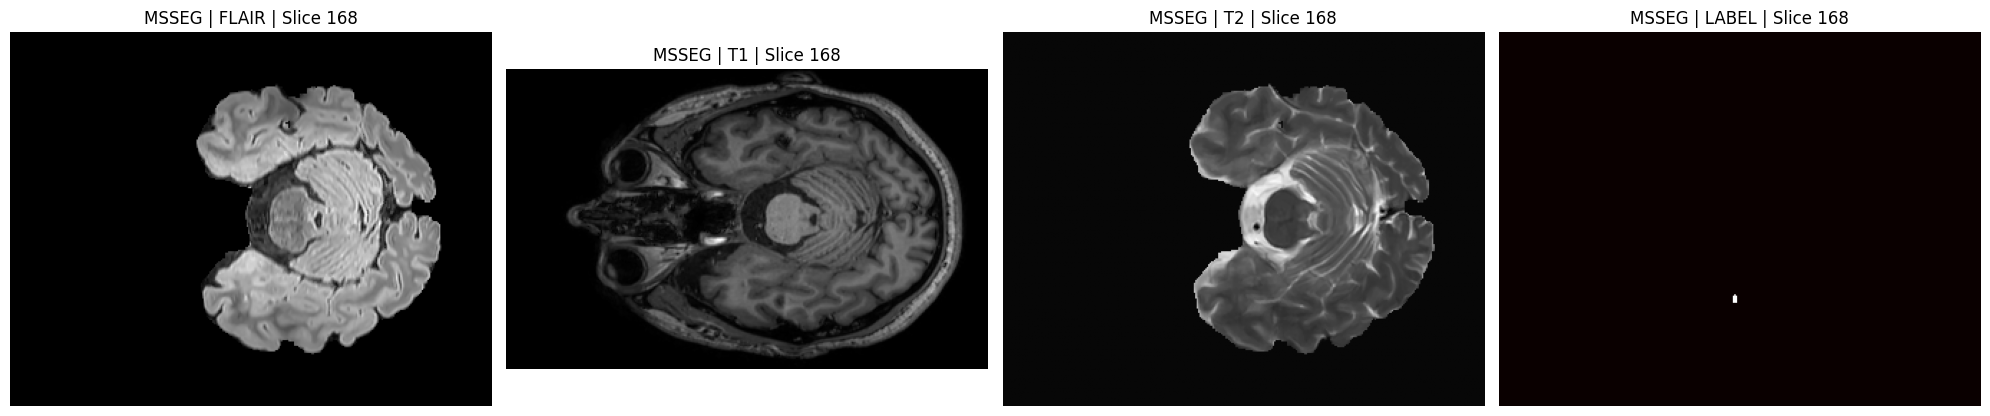

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(sample_dict, slice_idx=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    modalities = ["flair", "t1", "t2", "label"]

    for i, mod in enumerate(modalities):
        img = nib.load(sample_dict[mod]).get_fdata()
        current_slice = img.shape[2] // 2 if slice_idx is None else slice_idx
        cmap = "hot" if mod == "label" else "gray"
        axes[i].imshow(img[:, :, current_slice], cmap=cmap)
        axes[i].set_title(f"{sample_dict.get('source', 'case')} | {mod.upper()} | Slice {current_slice}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

if "data_dicts" in globals() and data_dicts:
    visualize_sample(data_dicts[0])